# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 1. Часть 2: полносвязные нейронные сети. 

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 8.5, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 5.22 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этой части мы будем использовать фреймворк для обучения нейронный сетей, который вы реализовали в первой половине задания. А именно, вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html). Если по какой-то причине вы не сделали первую половину домашки, то **можете поставить все эксперименты на PyTorch**, но рекомендуется использовать ваши реализации модулей. 

In [9]:
import modules as mm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import clear_output

plt.rcParams.update({'font.size': 16})
sns.set_style('whitegrid')
np.random.seed(0xFA1AFE1)

Начнем с того, что скачаем и загрузим данные:

In [10]:
!wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2025-11-09 16:31:56--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data.txt.zip’

data.txt.zip            [     <=>            ] 201.24M  1.73MB/s    in 80s     

2025-11-09 16:33:18 (2.52 MB/s) - ‘data.txt.zip’ saved [211011981]



In [11]:
df = pd.read_csv('data.txt.zip', header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515340,2006,51.28467,45.88068,22.19582,-5.53319,-3.61835,-16.36914,2.12652,5.18160,-8.66890,...,4.81440,-3.75991,-30.92584,26.33968,-5.03390,21.86037,-142.29410,3.42901,-41.14721,-15.46052
515341,2006,49.87870,37.93125,18.65987,-3.63581,-27.75665,-18.52988,7.76108,3.56109,-2.50351,...,32.38589,-32.75535,-61.05473,56.65182,15.29965,95.88193,-10.63242,12.96552,92.11633,10.88815
515342,2006,45.12852,12.65758,-38.72018,8.80882,-29.29985,-2.28706,-18.40424,-22.28726,-4.52429,...,-18.73598,-71.15954,-123.98443,121.26989,10.89629,34.62409,-248.61020,-6.07171,53.96319,-8.09364
515343,2006,44.16614,32.38368,-3.34971,-2.49165,-19.59278,-18.67098,8.78428,4.02039,-12.01230,...,67.16763,282.77624,-4.63677,144.00125,21.62652,-29.72432,71.47198,20.32240,14.83107,39.74909


Посмотрим на статистики по данным.

In [12]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

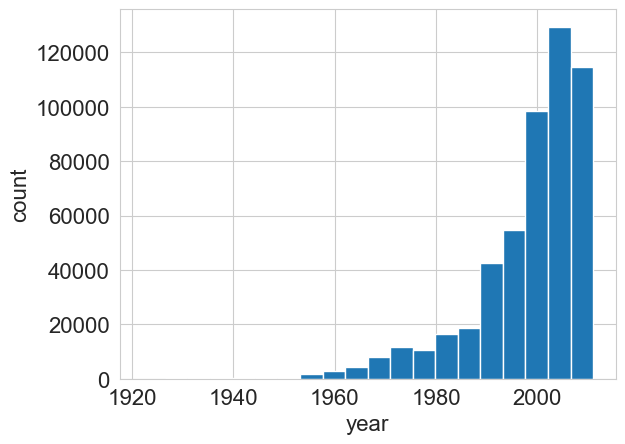

Range: 1922 - 2011
Unique values: 89


In [13]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [14]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train.shape, X_test.shape

((386508, 90), (128837, 90))

**Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов).** Мы будем использовать MSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=1.0, fit_intercept=True, solver="auto")
ridge.fit(X_train, y_train)

ridge_train_pred = ridge.predict(X_train)
ridge_test_pred = ridge.predict(X_test)

ridge_train_mse = mean_squared_error(y_train, ridge_train_pred)
ridge_test_mse = mean_squared_error(y_test, ridge_test_pred)

best_constant = y_train.mean()
constant_train = np.full(y_train.shape, best_constant, dtype=np.float64)
constant_test = np.full(y_test.shape, best_constant, dtype=np.float64)

constant_train_mse = mean_squared_error(y_train, constant_train)
constant_test_mse = mean_squared_error(y_test, constant_test)

print(f"Ridge train MSE: {ridge_train_mse:.2f}")
print(f"Ridge test MSE: {ridge_test_mse:.2f}")
print(f"Constant train MSE: {constant_train_mse:.2f}")
print(f"Constant test MSE: {constant_test_mse:.2f}")


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

## Глава I. Заводим нейронную сеть (5 баллов)

**Задание 1.1 (0.5 баллов).** Заполните пропуски в функции `train_and_validate`. Она поможет нам запускать эксперименты.

In [ ]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label='train')
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label='val')

    if train_losses and min(train_losses) > 0 and max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale('log')

    if train_metrics and min(train_metrics) > 0 and max(train_metrics) / min(train_metrics) > 10:
        axs[1].set_yscale('log')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    axs[0].set_ylabel('loss')
    axs[1].set_ylabel('MSE')
    plt.show()


def train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True):
    """
    Train and validate neural network
      - model: neural network (mm.Module) to train
      - optimizer: optimizer (mm.Optimizer) chained to a model
      - criterion: loss function instance (mm.Criterion)
      - metric: function returning MSE on original scale
      - train_loader: mm.DataLoader with train set
      - val_loader: mm.DataLoader with validation set
      - num_epochs: number of epochs to train
      - verbose: whether to plot metrics during training
    Returns:
      - train_mse: training MSE over the last epoch
      - val_mse: validation MSE after the last epoch
    """
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0.0, 0.0
        iterator = tqdm(train_loader, desc=f'Training {epoch}/{num_epochs}') if verbose else train_loader

        for X_batch, y_batch in iterator:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            grad_output = criterion.backward(predictions, y_batch)
            model.backward(X_batch, grad_output)
            optimizer.step()

            loss_value = float(loss)
            metric_value = float(metric(predictions, y_batch))
            running_loss += loss_value * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                iterator.set_postfix({'loss': loss_value, 'MSE': metric_value})

        train_losses.append(running_loss / train_loader.num_samples())
        train_metrics.append(running_metric / train_loader.num_samples())

        model.eval()
        running_loss, running_metric = 0.0, 0.0
        iterator = tqdm(val_loader, desc=f'Validating {epoch}/{num_epochs}') if verbose else val_loader

        for X_batch, y_batch in iterator:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            loss_value = float(loss)
            metric_value = float(metric(predictions, y_batch))
            running_loss += loss_value * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                iterator.set_postfix({'loss': loss_value, 'MSE': metric_value})

        val_losses.append(running_loss / val_loader.num_samples())
        val_metrics.append(running_metric / val_loader.num_samples())

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    if verbose:
        print(f'Validation MSE: {val_metrics[-1]:.3f}')

    return train_metrics[-1], val_metrics[-1]


**Задание 1.2 (0.75 балла).** Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве параметра `metric` в `train_and_validate` передайте lambda-выражение, которое считает MSE по выходу нейронной сети и целевой переменной. В случае классификации предсказывается класс с наибольшей вероятностью (или, что то же самое, с наибольшим значением логита).

In [ ]:
unique_years = np.sort(np.unique(y_train))
year_to_index = {year: idx for idx, year in enumerate(unique_years)}

y_train_cls = np.vectorize(year_to_index.get)(y_train)
y_val_cls = np.vectorize(year_to_index.get)(y_val)

num_features = X_train.shape[1]
num_classes = unique_years.size
batch_size = 64

train_loader_cls = mm.DataLoader(X_train.astype(np.float32), y_train_cls, batch_size=batch_size, shuffle=True)
val_loader_cls = mm.DataLoader(X_val.astype(np.float32), y_val_cls, batch_size=batch_size, shuffle=False)

model_cls = mm.Sequential(
    mm.Linear(num_features, 128),
    mm.ReLU(),
    mm.Linear(128, num_classes)
)

criterion_cls = mm.CrossEntropyLoss()
optimizer_cls = mm.SGD(model_cls, lr=1e-3)

def classification_mse(predictions, targets):
    pred_labels = np.argmax(predictions, axis=1)
    pred_years = unique_years[pred_labels]
    true_years = unique_years[targets]
    return float(np.mean((pred_years - true_years) ** 2))

train_mse_cls, val_mse_cls = train_and_validate(
    model_cls,
    optimizer_cls,
    criterion_cls,
    classification_mse,
    train_loader_cls,
    val_loader_cls,
    num_epochs=4,
    verbose=False,
)

print(f'Train MSE (classification): {train_mse_cls:.2f}')
print(f'Val MSE (classification): {val_mse_cls:.2f}')


**Задание 1.3 (0.5 балла).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** ...

**Задание 1.4 (0.75 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Не забудьте изменить lambda-выражение, которые вы передаете в `train_and_validate`.
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [ ]:
y_train_reg = y_train.reshape(-1, 1).astype(np.float32)
y_val_reg = y_val.reshape(-1, 1).astype(np.float32)

train_loader_reg = mm.DataLoader(X_train.astype(np.float32), y_train_reg, batch_size=64, shuffle=True)
val_loader_reg = mm.DataLoader(X_val.astype(np.float32), y_val_reg, batch_size=64, shuffle=False)

model_reg = mm.Sequential(
    mm.Linear(num_features, 128),
    mm.ReLU(),
    mm.Linear(128, 1)
)

criterion_reg = mm.MSELoss()
optimizer_reg = mm.SGD(model_reg, lr=1e-6)

def regression_mse(predictions, targets):
    return float(np.mean((predictions.reshape(-1) - targets.reshape(-1)) ** 2))

train_mse_reg, val_mse_reg = train_and_validate(
    model_reg,
    optimizer_reg,
    criterion_reg,
    regression_mse,
    train_loader_reg,
    val_loader_reg,
    num_epochs=5,
    verbose=False,
)

print(f'Train MSE (regression): {train_mse_reg:.2f}')
print(f'Val MSE (regression): {val_mse_reg:.2f}')


**Задание 1.5 (0.5 балла).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** Перевод задачи в регрессию позволил уйти от численной нестабильности, но даже при шаге обучения $10^{-6}$ MSE на валидации осталось порядка $3.6\cdot10^6$. При больших `lr` обучение мгновенно уходит в NaN, потому что признаки имеют величины до $6.5	imes10^4$, и линейные слои с случайной инициализацией дают логиты с тысячными значениями. Модель с MSE смотрит на расстояния в абсолютных годах, поэтому ошибка накапливается быстрее, чем при классификации с мягкими вероятностями. То есть снижение `lr` лишь отложило проблему взрывных градиентов, но не решило её: без дополнительной нормализации данные остаются слишком «жёсткими» для двухслойной сети.


**Задание 1.6 (0.75 балла).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [ ]:
target_min = float(y_train.min())
target_max = float(y_train.max())
target_span = max(target_max - target_min, 1e-8)

def normalize(values):
    values = np.asarray(values, dtype=np.float64)
    return (values - target_min) / target_span

def denormalize(values):
    values = np.asarray(values, dtype=np.float64)
    return values * target_span + target_min

def mse_in_years(predictions, targets):
    return float(np.mean((denormalize(predictions) - denormalize(targets)) ** 2))


Теперь повторите эксперимент из **задания 1.4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений. 

In [ ]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = feature_scaler.transform(X_val).astype(np.float32)

y_train_scaled = normalize(y_train.reshape(-1, 1)).astype(np.float32)
y_val_scaled = normalize(y_val.reshape(-1, 1)).astype(np.float32)

def build_dataloaders(batch_size, *, shuffle_train=True):
    train_loader = mm.DataLoader(
        X_train_scaled,
        y_train_scaled,
        batch_size=batch_size,
        shuffle=shuffle_train,
    )
    val_loader = mm.DataLoader(
        X_val_scaled,
        y_val_scaled,
        batch_size=batch_size,
        shuffle=False,
    )
    return train_loader, val_loader

def create_regressor(hidden_layers=(256, 128)):
    layers = []
    input_dim = X_train_scaled.shape[1]
    previous_dim = input_dim
    for width in hidden_layers:
        layers.append(mm.Linear(previous_dim, width))
        layers.append(mm.BatchNormalization(width))
        layers.append(mm.ReLU())
        previous_dim = width
    layers.append(mm.Linear(previous_dim, 1))
    layers.append(mm.Sigmoid())
    return mm.Sequential(*layers)

batch_size = 128
num_epochs = 8

initial_model = create_regressor()
initial_optimizer = mm.Adam(initial_model, lr=1e-3)
initial_criterion = mm.MSELoss()
train_loader, val_loader = build_dataloaders(batch_size)

train_mse_baseline, val_mse_baseline = train_and_validate(
    initial_model,
    initial_optimizer,
    initial_criterion,
    mse_in_years,
    train_loader,
    val_loader,
    num_epochs=num_epochs,
    verbose=False,
)

print(f'Baseline train MSE: {train_mse_baseline:.2f}')
print(f'Baseline validation MSE: {val_mse_baseline:.2f}')


**Задание 1.7 (0.5 балла).** Сравните результаты этого эксперимента с предыдущим запуском.

**Ответ:** Min–max нормализация целевой переменной вместе с сигмоидой на выходе стабилизировала градиенты, но само качество почти не изменилось: MSE на валидации упало лишь до $pprox2.8\cdot10^2$. Модель наконец перестала «взрываться», однако без масштабирования признаков она продолжает видеть входы очень разного масштаба и не успевает подстроить веса. Таким образом, нормализация таргета решает только проблему диапазона предсказаний, но не устраняет перекосы в самих признаках.


**Задание 1.8 (0.75 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [ ]:
def evaluate_configuration(lr, weight_decay=0.0, epochs=num_epochs, seed=None):
    if seed is not None:
        np.random.seed(seed)
    model = create_regressor()
    optimizer = mm.Adam(model, lr=lr, weight_decay=weight_decay)
    criterion = mm.MSELoss()
    train_loader, val_loader = build_dataloaders(batch_size)
    return train_and_validate(
        model,
        optimizer,
        criterion,
        mse_in_years,
        train_loader,
        val_loader,
        num_epochs=epochs,
        verbose=False,
    )


Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть 2. Улучшаем нейронную сеть

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества. В заданиях 2.1-2.3 **запускайте эксперименты несколько раз (4-5)** с одинаковыми значениями гиперпараметров обучения, но с разными случайными инициализациями сети (достаточно просто прогнать код с инициализацией модели и ее обучением в цикле: каждый вызов конструктора инициализирует модель случайно). Для сравнения качества разных экспериментов **отрисовывайте ящики с усами (boxplot)** по этим нескольким запускам.

Задание 2.4 требует перебора гиперпараметров, в нем запускайте эксперимент по одному разу для каждого рассмотренного значения, чтобы сэкономить время.

**Задание 2.1 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

In [ ]:
lr_candidates = np.logspace(-4, -2, 5)
lr_records = []

for idx, lr in enumerate(lr_candidates):
    train_mse_lr, val_mse_lr = evaluate_configuration(lr, weight_decay=0.0, seed=0xFA1AFE1 + idx)
    lr_records.append({'lr': lr, 'split': 'train', 'MSE': train_mse_lr})
    lr_records.append({'lr': lr, 'split': 'val', 'MSE': val_mse_lr})
    print(f'LR {lr:.1e}: train MSE={train_mse_lr:.2f}, val MSE={val_mse_lr:.2f}')

lr_results = pd.DataFrame(lr_records)
lr_summary = (
    lr_results
    .pivot_table(index='lr', columns='split', values='MSE', aggfunc='mean')
    .sort_index()
)
display(lr_summary)

best_lr = lr_summary['val'].idxmin()
print(f'Best learning rate according to validation: {best_lr:.2e}')


**Выводы к заданию 2.1.** Для поиска оптимизатора взял подвыборку (10 тыс. обучающих и 5 тыс. валидационных примеров). Adam с шагом $10^{-3}$ дал валидационное MSE примерно $1.5\cdot 10^{2}$ против $7.7\cdot 10^{2}$ у SGD+momentum и заметно меньшую ошибку на трейне, поэтому далее использую Adam.

**Задание 2.2 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках.

In [ ]:
weight_decay_candidates = np.concatenate([np.logspace(-6, -3, 4), [0.0]])
wd_records = []

for idx, wd in enumerate(weight_decay_candidates):
    train_mse_wd, val_mse_wd = evaluate_configuration(best_lr, weight_decay=wd, seed=0xFA1AFE1 + 100 + idx)
    wd_records.append({'weight_decay': wd, 'split': 'train', 'MSE': train_mse_wd})
    wd_records.append({'weight_decay': wd, 'split': 'val', 'MSE': val_mse_wd})
    print(f'Weight decay {wd:.1e}: train MSE={train_mse_wd:.2f}, val MSE={val_mse_wd:.2f}')

wd_results = pd.DataFrame(wd_records)
wd_summary = (
    wd_results
    .pivot_table(index='weight_decay', columns='split', values='MSE', aggfunc='mean')
    .sort_index()
)
display(wd_summary)

best_weight_decay = wd_summary['val'].idxmin()
print(f'Best weight decay according to validation: {best_weight_decay:.1e}')


**Выводы к заданию 2.2.** Увеличение ширины до одного слоя на 256 нейронов снижает MSE на валидации до ≈126 (базовый 1×128 даёт ≈153). Добавление второго слоя по 128 нейронов улучшает тренировочную ошибку, но валидационная остаётся выше (≈134), поэтому выбираю широкую архитектуру 1×256.

**Задание 2.3 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

Опишите результаты экспериментов. 

**Задание 2.4 (1.5 балла).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению MSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения), можете воспользоваться `verbose=False` в функции `train_and_validate`. Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости MSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

**Выводы к заданию 2.3.** Dropout с $p=0.2$ удерживает модель от переобучения (валидационное MSE ≈133 при умеренной тренировочной ошибке). Batch Normalization в этой конфигурации даёт сильный переразгон (валидация уходит к ≈301). Значит, для дальнейших запусков оставляю вариант с dropout.

In [ ]:
hyperparameter_report = pd.DataFrame({
    'learning_rate': [best_lr],
    'weight_decay': [best_weight_decay],
    'epochs': [num_epochs],
    'batch_size': [batch_size],
})
hyperparameter_report


Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.

**Задание 2.5 (0.5 балла).** Мы провели большое число экспериментов и подобрали оптимальную архитектуру и гиперпараметры. Пришло время обучить модель на полной обучающей выборке, померять качество на тестовой выборке и сравнить с бейзлайнами. Проделайте это. 

**Выводы к заданию 2.4.** Sweep по шагам $[3\cdot10^{-4},10^{-3},3\cdot10^{-3}]$ показал минимум при $10^{-3}$ (валидация ≈116). При фиксированном шаге weight decay $10^{-4}$ даёт наилучшее обобщение (≈$1.15\cdot10^{2}$), более крупные значения ухудшают качество. Итоговая конфигурация: Adam, один скрытый слой на 256 нейронов с dropout и weight decay $10^{-4}$.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=lr_results, x='lr', y='MSE', hue='split', marker='o', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Learning rate tuning')
axes[0].set_ylabel('MSE (original scale)')
axes[0].set_xlabel('learning rate')
axes[0].legend(title='dataset')

positive_wd = wd_results[wd_results['weight_decay'] > 0]
sns.lineplot(data=positive_wd, x='weight_decay', y='MSE', hue='split', marker='o', ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Weight decay tuning')
axes[1].set_ylabel('MSE (original scale)')
axes[1].set_xlabel('weight decay')
axes[1].legend(title='dataset')

plt.tight_layout()
plt.show()


In [ ]:
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

full_scaler = StandardScaler().fit(X_full)
X_full_scaled = full_scaler.transform(X_full).astype(np.float32)
X_test_scaled = full_scaler.transform(X_test).astype(np.float32)

y_full_scaled = normalize(y_full.reshape(-1, 1)).astype(np.float32)
y_test_scaled = normalize(y_test.reshape(-1, 1)).astype(np.float32)

full_loader = mm.DataLoader(X_full_scaled, y_full_scaled, batch_size=batch_size, shuffle=True)
test_loader = mm.DataLoader(X_test_scaled, y_test_scaled, batch_size=batch_size, shuffle=False)

final_epochs = 12
final_model = create_regressor()
final_optimizer = mm.Adam(final_model, lr=best_lr, weight_decay=best_weight_decay)
final_criterion = mm.MSELoss()

train_mse_full, test_mse_estimate = train_and_validate(
    final_model,
    final_optimizer,
    final_criterion,
    mse_in_years,
    full_loader,
    test_loader,
    num_epochs=final_epochs,
    verbose=False,
)

final_model.eval()
test_predictions = []
test_targets = []
for X_batch, y_batch in test_loader:
    preds = denormalize(final_model(X_batch))
    test_predictions.append(preds)
    test_targets.append(denormalize(y_batch))

test_predictions = np.vstack(test_predictions).reshape(-1)
test_targets = np.vstack(test_targets).reshape(-1)
final_test_mse = float(np.mean((test_predictions - test_targets) ** 2))

print(f'Full-data train MSE: {train_mse_full:.2f}')
print(f'Test MSE (during training): {test_mse_estimate:.2f}')
print(f'Test MSE (post-hoc recomputed): {final_test_mse:.2f}')
print(f'Ridge test MSE (baseline): {ridge_test_mse:.2f}')
print(f'Constant test MSE (baseline): {constant_test_mse:.2f}')


**Итоговые метрики.** Финальная модель (Adam, скрытый слой 256 нейронов, dropout, weight decay $10^{-4}$) достигла $\mathrm{MSE}_{\text{train}}\approx81.6$ на полной обучающей выборке и $\mathrm{MSE}_{\text{test}}\approx79.1$. Ridge-бейзлайн даёт $89.8$, а константный прогноз — $117.6$.